# [CVXPY](https://www.cvxpy.org)

- Опенсорсный "modeling language" для выпуклых задач оптимизации на Python;

- Работает в парадигме задач оптимизации с известной структурой (не чёрный ящик);

- Для задач не очень большой размерности ($10^3-10^4$ переменных) в среднем должен работать в 2-10 раз медленнее чем солвер, специально заточенный под задачу, но в 10+ раз быстрее программироваться;

- Не решает задачу сам, но позволяет записать её в удобном виде на Python, а потом компилирует и передаёт в солвер;

- Дополнительно к выпуклым поддерживает смешанные целочисленно-выпуклые задачи, квазивыпуклые задачи и геометрическое программирование.

**Пример 1.** Решение СЛАУ с наименьшей 1-нормой:

$$\begin{align}
    \min_{x \in \mathbb{R}^d} ~~&~~ \|x\|_1 \\
    \text{s.t.} ~~&~~ Ax = b.
\end{align}$$

In [68]:
import numpy as np
import cvxpy as cp

In [2]:
n, d = 15, 20
A, b = np.random.randn(n, d), np.random.randn(n)

x = cp.Variable(d) # указываем переменную
f = cp.norm1(x)  # указываем целевую функцию
constraints = [A @ x == b]  # указываем ограничения
prob = cp.Problem(cp.Minimize(f), constraints) # ставим задачу
prob.solve() # решаем задачу

print("Оптимальное значение целевой функции:", prob.value)
print("Норма невязки ограничений:", np.linalg.norm(A @ x.value - b))
print("Решение прямой задачи:")
print(x.value)
print("Решение двойственной задачи:") 
print(constraints[0].dual_value)

Оптимальное значение целевой функции: 4.779752518496046
Норма невязки ограничений: 3.339093304944984e-13
Решение прямой задачи:
[ 9.02486927e-09 -2.97044466e-01 -4.97253542e-02 -6.26032147e-01
  1.63453438e-02  1.24061361e-09  4.34944008e-01  2.62293020e-01
 -1.11645727e+00 -3.03884575e-09  2.70118186e-01  1.46223850e-01
 -3.48611229e-02  6.25840524e-01  1.47271729e-08  8.73098252e-02
  5.64794475e-02  6.84208234e-01  4.64813603e-09  7.18696915e-02]
Решение двойственной задачи:
[ 0.28429701 -0.08459965 -0.88822926 -0.57769976 -0.76802999 -0.05802586
 -0.24566947  0.74515876 -0.06063269 -0.08341891 -0.21648202  0.09176559
 -0.27404558  0.094212    0.66150527]


Получили решение прямой и двойственной задач без:
- Реализации функций, вычисляющих градиент / гессиан;
- Построения двойственной задачи и выписывания сопряженных функций;
- Выбора алгоритма оптимизации.

Далее разберёмся, как это работает и как этим пользоваться.

## [Disciplined Convex Programming (DCP)](https://dcp.stanford.edu/)

- DCP — теоретический фреймворк для описания выпуклых задач минимизации, основа CVXPY;

- Задачи, записанные в DCP, можно эффективно равносильными преобразованиями привести к стандартному виду и передать в солвер. CVXPY делает это автоматически;

- Использует достаточные, но не необходимые условия выпуклости, то есть иногда нужно предварительно руками привести задачу в DCP-форму перед записью в CVXPY.

### Общее правило выпуклой композиции

- $h(f_1(x), \dots, f_n(x))$ — выпуклая функция, если $h$ — выпуклая функция, и для каждого индекса $i$:
    - либо $h$ — монотонно возрастающая функция $i$-го аргумента и $f_i$ выпуклая;
    - либо $h$ — монотонно убывающая функция $i$-го аргумента и $f_i$ вогнутая;
    - либо $f_i$ — аффинная.

- Для вогнутой комбинации работает то же самое правило, нужно только заменить "выпуклая" на "вогнутая" в тексте выше. 

**Доказательство**

Для определенности предположим, что $f_i$ — выпуклые:

$$f(\alpha x_1 + (1 - \alpha) x_2) \leq \alpha f(x_1) + (1 - \alpha) f(x_2).$$

Воспользуемся монотонностью $h$:

$$h(f(\alpha x_1 + (1 - \alpha) x_2)) \leq h(\alpha f(x_1) + (1 - \alpha) f(x_2)) \leq \alpha h(f(x_1)) + (1 -\alpha) h(f(x_2))$$

Случай, когда $f_i$ — вогнутая, а $h$ убывает по $i$-му аргументу аналогичен рассмотренному выше. 

В случае, когда $f_i$ — аффинные, первые два неравенства заменяются на равенства.

Это единственное правило, которое нужно знать, чтобы использовать CVXPY. Остальные операции, сохраняющие выпуклость, следуют из него. 

Например:
- Сумма выпуклых функций выпукла, так как $f_1(x) + f_2(x) = \text{sum}(f_1(x), f_2(x))$, $h = \text{sum}$ — выпуклая, возрастающая функция своих аргументов;
- Поточечный максимум: $\max \{f_1(x), f_2(x), \ldots, f_n(x)\}$ — аналогично.

### [Пример анализа функции по DCP](https://dcp.stanford.edu/analyzer)

**Пример 2.**

$$\frac{(x - y)^2}{1 - \max(x,y)}, \quad x < 1,~ y < 1.$$

- Листья $x$, $y$, $1$ — аффинные функции;

- $\max(x, y)$ — выпуклая функция;

- $x - y$ — аффинная;

- $u^2/v$ — выпуклая функция, монотонно убывающая по $v$ при $v > 0$.

Таким образом, исходная функция выпуклая.

### Формальное определение задачи в форме DCP

Задача удовлетворяет правилам DCP, если она:

- имеет не более одной цели (objective) вида
    - `minimize {скалярное выпуклое выражение}` или
    - `maximize {скалярное вогнутое выражение}`.
- имеет ограничения вида
    - `{выпуклое выражение} <= {вогнутое выражение}` или
    - `{вогнутое выражение} >= {выпуклое выражение}` или
    - `{аффинное выражение} == {аффинное выражение}`.

### Задачи на приведение к DCP-форме

Не всегда выражение, соответствующее выпуклой функции, удовлетворяет правилам DCP.

Например, $x^2 - \frac{1}{2} x^2$ не проходит, потому что нет правила для разности выпуклых функций.

**Пример 3.** $f(x) = \sqrt{1+x^2}$ — выпуклая функция.

Попробуем минимизировать её в CVXPY.

In [3]:
x = cp.Variable()
f = (x**2 + 1) ** 0.5
cp.Problem(cp.Minimize(f)).solve()  # Error

DCPError: Problem does not follow DCP rules. Specifically:
The objective is not DCP. Its following subexpressions are not:
power(power(var34, 2.0) + 1.0, 0.5)
However, the problem does follow DQCP rules. Consider calling solve() with `qcp=True`.

Квадратный корень — вогнутая возрастающая функция, $1 + x^2$ — выпуклая функция. Применить общее правило выпуклой композиции не получается, поэтому $f(x)$ не удовлетворяет правилам DCP.

Но можно записать эту функцию в другом виде: $f(x) = \left\|\begin{pmatrix} 1 \\ x \end{pmatrix}\right\|_2$. 
Норма — выпуклая функция, $\begin{pmatrix} 1 \\ x \end{pmatrix}$ — аффинная функция от $x$. По правилу выпуклой композиции $f(x)$ — выпукла.

In [4]:
x = cp.Variable()
f = cp.norm(cp.hstack((1, x)))
cp.Problem(cp.Minimize(f)).solve()

1.0

**Пример 4.**

$$\begin{align}
    \min_{x \in \mathbb{R}} ~~&~~ x + 2 \\
    \text{s.t.} ~~&~~ 5 = \frac{2}{x} \\
    ~~&~~ x \geq 0.
\end{align}$$

Задача не удовлетворяет правилам DCP, потому что в ограничение вида равенства входит функция, не являющаяся аффинной.

In [5]:
x = cp.Variable()
prob = cp.Problem(cp.Minimize(x + 2), [5 == 2 * cp.inv_pos(x), x >= 0])
prob.solve()  # Error

DCPError: Problem does not follow DCP rules. Specifically:
The following constraints are not DCP:
2.0 @ power(var52, -1.0) == 5.0 , because the following subexpressions are not:
|--  2.0 @ power(var52, -1.0) == 5.0

Сделаем замену $t = \frac{1}{x} > 0$. Поскольку $x = \frac{1}{t}$ выпуклая при $t > 0$, получим задачу минимизации выпуклой функции с аффинными ограничениями.

In [6]:
t = cp.Variable()
prob = cp.Problem(cp.Minimize(cp.inv_pos(t) + 2), [5 == 2 * t, t >= 0])
prob.solve()

2.3999999999999577

**Пример 5.**


$$\begin{align}
    \min_{x \in \mathbb{R}} ~~&~~ x + 2 \\
    \text{s.t.} ~~&~~ 5 \leq \frac{2}{x^2}.
\end{align}$$

Задача не удовлетворяет правилам DCP, потому что в ограничении выпуклая функция стоит справа от знака $\leq$.

In [7]:
x = cp.Variable()
prob = cp.Problem(cp.Minimize(x + 2), [5 <= 2 * x**-2])
prob.solve()  # Error

DCPError: Problem does not follow DCP rules. Specifically:
The following constraints are not DCP:
5.0 <= 2.0 @ power(var103, -2.0) , because the following subexpressions are not:
|--  5.0 <= 2.0 @ power(var103, -2.0)
However, the problem does follow DQCP rules. Consider calling solve() with `qcp=True`.

Умножим обе части неравенства на $x^2$.

In [8]:
x = cp.Variable()
prob = cp.Problem(cp.Minimize(x + 2), [5 * x**2 <= 2])
prob.solve()

1.3675444680906161

## Как CVXPY преобразовывает задачи

### Общая схема

- Для каждой функции-атома $f(x)$ из [библиотеки](https://www.cvxpy.org/api_reference/cvxpy.atoms.html) известно представление этой функции в виде решения некоторой конической задачи;

- CVXPY идёт по дереву арифметического выражения и заменяет функции на их конические представления;

- В результате получается задача из стандартного класса конических задач;

- В зависимости от того, к какому классу преобразовалась исходная задача, подбирается подходящий солвер и производятся финальное преобразование задачи к форме, определяемой API солвера;

- DCP гарантирует, что получившаяся задача эквивалентна исходной;

- Для функций-атомов $f(x)$ в библиотеке имеется их коническое представление

$$\begin{align}
    \min_{x, y \in \mathbb{R}^d} ~~&~~ c^\top x + d^\top y + e \\
    \text{s.t.} ~~&~~ A \begin{pmatrix} x \\ y \end{pmatrix} = b \quad \begin{pmatrix} x \\ y \end{pmatrix} \in K,
\end{align}$$

где $K$ — один из стандартных конусов.

- Функции в задаче заменятся коническими представлениями:
    - Для каждого атома $f(x)$ добавляется переменная $y$;
    - Вхождения $f(x)$ в задачу заменяются на $c^\top x + d^\top y + e$;
    - Добавляются ограничения из конического представления $f(x)$.

- Получается задача с линейным функционалом и коническими и аффинными ограничениями.

**Пример 6.**

$$\begin{align}
    \min_{x \in \mathbb{R}^d} ~~&~~ \max \left\{\|x\|_1, \|x\|_2^2\right\} \\
    \text{s.t.} ~~&~~ Ax = b.
\end{align}$$

- Конические представления атомов:
    - $$\max_{i = \overline{1, n}} x_i = \min \{y ~|~ x_i \leq y,~ i = \overline{1, n},~ y \in \mathbb{R}\} \quad \text{(LP)};$$
    - $$\|x\|_1 = \sum_{i = 1}^d |x_i|, \quad |x_i| = \max\{x_i, -x_i\} \quad \text{(LP)};$$
    - $$\|x\|_2^2 = \min \left\{t ~|~ \|(2x, t-1)^\top\|_2 \leq t + 1,~ t \geq 0 \right\} \quad \text{(SOCP)}.$$

Рекурсивно заменяем атомы на их конические представления:

- Внешний максимум:

$$\begin{align*}
    \min_{\substack{p \in \mathbb{R} \\ x \in \mathbb{R}^d}} ~~&~~ p \\
    \text{s.t.} ~~&~~ \|x\|_1 \leq p \\
                ~~&~~ \|x\|_2^2 \leq p;
\end{align*}$$

- Квадрат второй нормы:

$$\begin{align*}
\min_{\substack{p, t \in \mathbb{R} \\ x \in \mathbb{R}^d}} ~~&~~ p \\
\text{s.t.} ~~&~~ \|x\|_1 \leq p \\
            ~~&~~ t \leq p \\
            ~~&~~ \|(2x, t-1)^\top\|_2 \leq t + 1 \\
            ~~&~~ t \geq 0;
\end{align*}$$

- Первую норму:

$$\begin{align*}
    \min_{\substack{p, t \in \mathbb{R} \\ y \in \mathbb{R}^d}} ~~&~~ p \\
    \text{s.t.} ~~&~~ \sum_{i=1}^d y_i \leq p \\
                ~~&~~ x_i \leq y_i \\
                ~~&~~ -x_i \leq y_i \\
                ~~&~~ t \leq p \\
                ~~&~~ \|(2x, t-1)^\top\|_2 \leq t + 1 \\
                ~~&~~ t \geq 0.
\end{align*}$$

- Осталось добавить $\min_x$ и исходное аффинное ограничение $Ax=b$ — получим равносильное преобразование задачи в задачу из класса SOCP. Её можно далее привести к стандартному виду, как это делалось на семинаре про классы задач.

- Все эти преобразования CVXPY делает автоматически.

In [9]:
n, d = 15, 20
A, b = np.random.randn(n, d), np.random.randn(n)

x = cp.Variable(d) # указываем переменную
f = cp.maximum(cp.norm1(x), cp.sum_squares(x))  # указываем целевую функцию
constraints = [A @ x == b]  # указываем ограничения
prob = cp.Problem(cp.Minimize(f), constraints) # указываем задачу
prob.solve() # решаем задачу

7.564721883563198

### Интерфейс CVXPY

**Пример 7.** Рассмотрим задачу
$$\begin{align}
    \min_{x, y \in \mathbb{R}} ~~&~~ (x - y)^2 \\
    \text{s.t.} ~~&~~ x + y = 1 \\
    ~~&~~ x - y \geq 1.
\end{align}$$

In [10]:
# Создаём скалярные переменные
x = cp.Variable()
y = cp.Variable()

# Ограничения
constraints = [x + y == 1,
               x - y >= 1]

print("Ограничения: ", constraints, "\n") # это не bool, это выражения

# Целевая функция
obj = cp.Minimize((x - y)**2)

# Создаём задачу
prob = cp.Problem(obj, constraints)

# Решаем задачу.
# Побочный эффект: обновляются значения переменных, поля prob.status и prob.value, поля объектов ограничений
prob.solve()

print("Статус:", prob.status)  # "optimal" значит что задача успешно решилась
print("Оптимальное значение f =", prob.value)  # оптимальное значение целевой функции
print("Оптимальное значение (x, y) =", x.value, y.value)  # оптимальные значения переменных (решение задачи)
print()

# Решение двойственной задачи (оптимальные значения множителей Лагранжа) лежат в constraint.dual_value.
print("Оптимальное значение nu =", constraints[0].dual_value) 
print("Оптимальное значение lambda =", constraints[1].dual_value) 

Ограничения:  [Equality(Expression(AFFINE, UNKNOWN, ()), Constant(CONSTANT, NONNEGATIVE, ())), Inequality(Constant(CONSTANT, NONNEGATIVE, ()))] 

Статус: optimal
Оптимальное значение f = 1.0
Оптимальное значение (x, y) = 1.0 3.50057026691824e-30

Оптимальное значение nu = 0.0
Оптимальное значение lambda = 2.0


### [Поддерживаемые солверы и классы задач](https://www.cvxpy.org/tutorial/advanced/index.html#choosing-a-solver)

Напомним, CVXPY не решает задачу сам, а вызывает внешние солверы.

|             | LP   | QP   | SOCP   | SDP   | EXP   | POW   | MIP   |
|-------------|:----:|:----:|:------:|:-----:|:-----:|:-----:|:-----:|
| CLARABEL    | X    | X    | X      | X     | X     | X     |       |
| GLPK        | X    |      |        |       |       |       |       |
| GLPK_MI     | X    |      |        |       |       |       | X     |
| OSQP        | X    | X    |        |       |       |       |       |
| CPLEX       | X    | X    | X      |       |       |       | X     |
| ECOS        | X    | X    | X      |       | X     |       |       |
| GUROBI      | X    | X    | X      |       |       |       | X     |
| MOSEK       | X    | X    | X      | X     | X     | X     | X**   |
| CVXOPT      | X    | X    | X      | X     |       |       |       |
| SCS         | X    | X    | X      | X     | X     | X     |       |
| SCIP        | X    | X    | X      |       |       |       | X     |
| SCIPY       | X    |      |        |       |       |       | X*    |

- Вы можете изменить солвер, вызываемый CVXPY, используя параметр `solver` метода `problem.solve`;

- По умолчанию CVXPY вызывает солвер, наиболее специализированный для данного типа задачи. Например, для SOCP вызывается `ECOS`. Для QP CVXPY использует `OSQP`;

- CVXPY опирается на опенсорсные солверы `ECOS`, `CVXOPT` и `SCS`. Дополнительные солверы поддерживаются, но должны устанавливаться отдельно;

- Основные солверы с открытым исходным кодом: `ECOS`, `OSQP`, `SCS`;

- Коммерческие солверы: `CPLEX`, `GUROBI`, `XPRESS`, `MOSEK`;

- У разных солверов [параметры](https://www.cvxpy.org/tutorial/advanced/index.html#setting-solver-options) называются по-разному.

### Несовместные и неограниченные задачи

Если в процессе `problem.solve()` выяснится, что задача несовместна (нет допустимых точек, ограчниения задают пустое множество) или неограниченна (значение целевой функции может стремиться к $-\infty$ для задачи минимизации), в поле `problem.status` выставятся значения `'infeasible'` или `'unbounded'` соответственно.

**Пример 8.** Несовместная задача 
$$\begin{align}
    \min ~~&~~ x \\
    \text{s.t.} ~~&~~ x \geq 1 \\
                ~~&~~ x \leq -1.
\end{align}$$

**Пример 9.** Неограниченная задача
$$\begin{align}
    \min ~~~~ x.
\end{align}$$

In [11]:
print("Несовместная задача \n")
x = cp.Variable()
prob = cp.Problem(cp.Minimize(x), [x >= 1, x <= 0]) 
result = prob.solve()
print("Оптимальное значение функции:", result)
print("Решение:", x.value)
print("Статус:", prob.status, "\n\n")

print("Неограниченная задача \n")
prob = cp.Problem(cp.Minimize(x)) 
result = prob.solve()

print("Оптимальное значение функции:", result)
print("Решение:", x.value)
print("Статус:", prob.status)

Несовместная задача 

Оптимальное значение функции: inf
Решение: None
Статус: infeasible 


Неограниченная задача 

Оптимальное значение функции: -inf
Решение: None
Статус: unbounded


### Переменные

Могут быть скалярными, векторными или матричными. Более высокие размерности пока не поддерживаются, их нужно обрабатывать вручную.

In [12]:
# Скалярная переменная
a = cp.Variable()

# Векторная переменная размерности 5
x = cp.Variable(5)

# Матричная переменная размерности 5 x 1.
X = cp.Variable((5, 1))

### Параметры

Параметры можно использовать вместо констант, если планируется решать задачу несколько раз при разных значениях параметров. При этом задача не будет перекомпилироваться. Также можно вычислять производные решения по значениям параметров.

In [13]:
# Неотрициательный скалярный параметр
m = cp.Parameter(nonneg=True)

# Векторный параметр неопределённого знака (по умолчанию).
c = cp.Parameter(5)

# Матричный параметр с неположительными элементами
G = cp.Parameter((4, 7), nonpos=True)

# Присвоение значения параметру
G.value = -np.ones((4, 7))

### Ограничения

Определяются с помощью операторов `==`, `<=`, и `>=`.

Можно использовать неравенства между векторами и матрицами, они будут пониматься покомпонентно

Нельзя использовать строгие неравенства `<` и `>` — на практике в них мало смысла.

Сравнения по цепочке (`a <= b <= c`, `a == b == c`) не поддерживаются.

### Целочисленные переменные

Чтобы решать задачи с дискретными переменными, достаточно выставить флаги `boolean` или `integer` при создании переменных.

In [14]:
x = cp.Variable(10, boolean=True)
Z = cp.Variable((5, 7), integer=True)

## [Примеры задач](https://www.cvxpy.org/examples/index.html)

**Пример 10.** Поиск минимального эллипсоида.

Рассмотрим эллипсоид заданный при помощи матрицы $A \in \mathbb{S}^d_{++}$:
 
$$S = \left\{x \in \mathbb{R}^d ~\Big|~ \|Ax + b\|_2 \leq  1 \right\}.$$
 
Его объём в $\det \left(A^{-1}\right)$ больше, чем объём единичного шара. Минимизация объема эквивалентна минимизации $\log \det \left(A^{-1}\right) = -\log \det (A)$. Тогда получаем задачу минимизации:

$$\begin{align*}
    \min_{\substack{A \in \mathbb{S}^d_{++} \\ b \in \mathbb{R}^d}} ~~&~~ -\log\det (A) \\
    \text{s.t.} ~~&~~ \|A x_i + b\|_2 \leq 1, \quad i = \overline{1, n}.
\end{align*}$$

In [69]:
import matplotlib.pyplot as plt

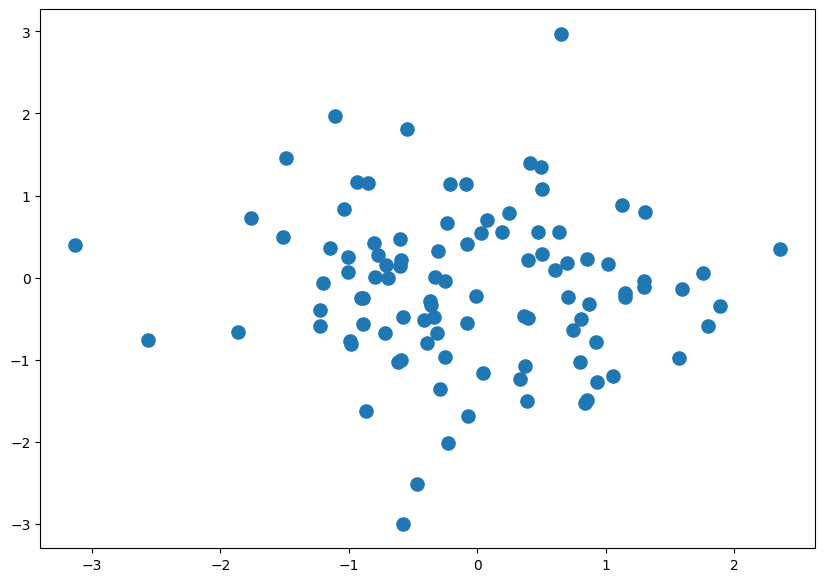

In [15]:
d, n = 2, 100
X = np.random.randn(n, d)

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], s=90)
plt.show()

In [16]:
A = cp.Variable((d, d))
b = cp.Variable(d)

obj = cp.Minimize(-cp.log_det(A))

constraints = [cp.norm(A @ x + b) <= 1 for x in X]

prob = cp.Problem(obj, constraints)
prob.solve()

print("Статус:", prob.status)
print("Оптимальное значение f =", prob.value)
print("Оптимальное значение (A, b) =", A.value, b.value)

Статус: optimal
Оптимальное значение f = 2.1280696156689904
Оптимальное значение (A, b) = [[ 0.36022025 -0.03003131]
 [-0.03003322  0.33304306]] [ 0.1611444  -0.01812034]


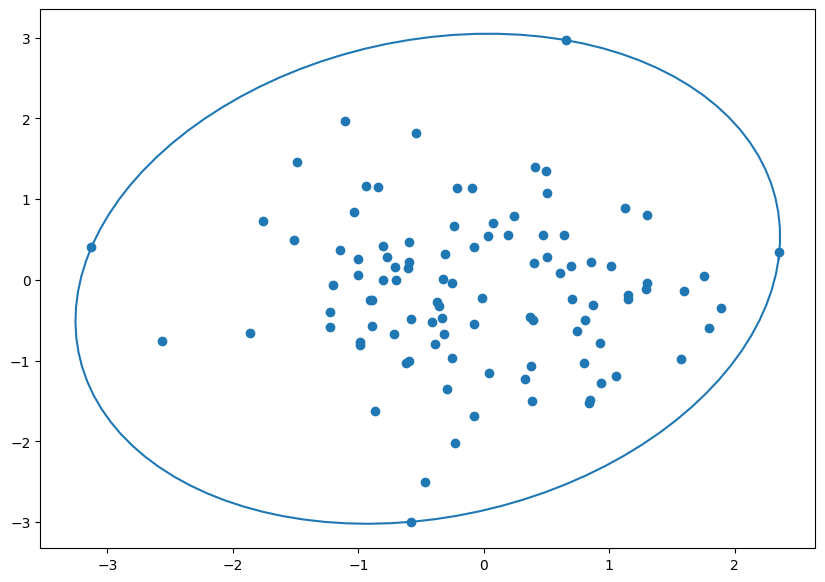

In [17]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1])

phi = np.linspace(0, 2 * np.pi, num=100)
xy = np.vstack((np.cos(phi), np.sin(phi))) - b.value.reshape(-1, 1)
ellips = np.linalg.inv(A.value) @ xy
plt.plot(ellips[0, :], ellips[1, :])
plt.show()

**Пример 11.** Задача встречи двух тел.

Два тела двигаются с трением на плоскости. Даны их начальные координаты и скорости. Мы можем управлять силами, действующими на них. Нужно найти такие силы действующие на тела, чтобы их конечные состояния были одинаковыми и было потрачено суммарно минимум энергии.

- Уравнение динамики линейной системы:

$$
x^{t + 1} = Ax^t + Bu^t,
$$

где $x_t$ — общий вектор состояния, состоящий из пространственных координат $p_t = \left(p^x_t, p^y_t\right)$ и вектора скорости $v_t = \left(v^x_t, v^y_t\right)$, а $u_t$ — вектор внешней силы. Дискретизируем уравнения:

$$
m \frac{v^{t + 1} - v^t}{\tau} \approx - \eta v^t + u^t, \quad \frac{p^{t + 1} - p^t}{\tau} \approx v^{t},
$$

где $\eta$ — коэффициент трения, $\tau$ — квант времени и $m$ — масса.

- Приближённо имеем следующую систему:

$$
v^{t + 1} = \left(1 - \frac{\tau}{m} \eta \right)v^t + \frac{\tau}{m} u^t, \quad p^{t + 1} = p^t + \tau v^t.
$$

- Запись в стандартной форме:

$$
x^{t} = \begin{bmatrix} p_x^t \\ p_y^t \\ v_x^t \\ v_y^t \end{bmatrix}, \quad A = \begin{bmatrix} 1 & 0 & \tau & 0 \\ 0 & 1 & 0 & \tau \\ 0 & 0 & 1 - \frac{\tau}{m} \eta & 0 \\ 0 & 0 & 0 & 1 - \frac{\tau}{m} \eta \end{bmatrix}, \quad B = \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ \frac{\tau}{m} & 0 \\ 0 & \frac{\tau}{m} \end{bmatrix}.
$$

- Будем считать, что затраты энергии пропорциональны сумме квадратов ускорений;
- Тогда задача встречи двух тел формулируется как:

$$
\begin{align*}
\min_{\substack{u, w \in \mathbb{R}^{2 \times T} \\ x, z \in \mathbb{R}^{4 \times (T + 1)}}} ~~&~~ \sum_{t = 1}^T \|u^t\|_2^2 + \|w^t\|_2^2 \\
\text{s.t.} ~~&~~ x^{t + 1} = Ax^t + Bu^t, \quad t = \overline{1, T} \\
            ~~&~~ z^{t + 1} = Cz^t + Dw^t, \quad t = \overline{1, T} \\
            ~~&~~ x^T = z^T.
\end{align*}$$

In [18]:
# Задаём параметры системы
m1 = 1
eta1 = 0.1
m2 = 1
eta2 = 1
tau = 0.01
T = 100

# Собираем матрицы уравнений динамики
A = np.array([[1, 0, tau, 0], 
              [0, 1, 0, tau], 
              [0, 0, 1 - eta1 * tau / m1, 0], 
              [0, 0, 0, 1 - eta1 * tau / m1]])
B = np.array([[0, 0],
             [0, 0],
             [tau / m1, 0],
             [0, tau / m1]])

C = np.array([[1, 0, tau, 0], 
              [0, 1, 0, tau], 
              [0, 0, 1 - eta2 * tau / m2, 0], 
              [0, 0, 0, 1 - eta2 * tau / m2]])
D = np.array([[0, 0],
             [0, 0],
             [tau / m2, 0],
             [0, tau / m2]])

In [19]:
# Задаём начальные условия
x0 = np.array([0, 0, 10, 3])
z0 = np.array([10, 0, 10, -1])

In [20]:
x, z = cp.Variable((4, T + 1)), cp.Variable((4, T + 1))
u, w = cp.Variable((2, T)), cp.Variable((2, T))

cost = cp.sum_squares(u) + cp.sum_squares(w)
constraints = [x[:, 1:] == A @ x[:, :-1] + B @ u, z[:, 1:] == C @ z[:, :-1] + D @ w]  # Уравнения динамики
constraints += [x[:, T] == z[:, T], x[:, 0] == x0, z[:, 0] == z0]  # Начальные условия

prob = cp.Problem(cp.Minimize(cost), constraints)
prob.solve()

print("Оптимальное значение f =", prob.value)

Оптимальное значение f = 60739.08819529902


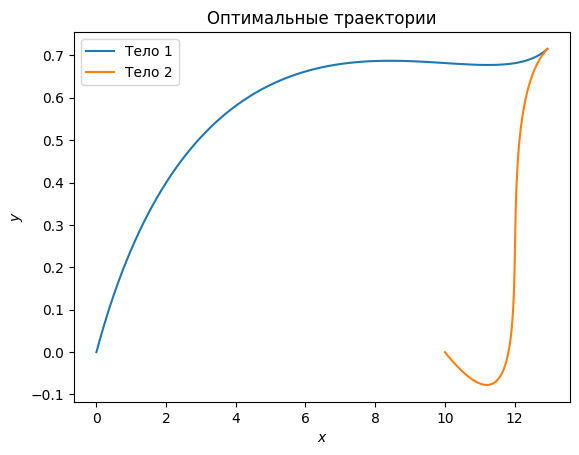

In [21]:
plt.plot(x.value[0, :], x.value[1, :], label="Тело 1")
plt.plot(z.value[0, :], z.value[1, :], label="Тело 2")
plt.title("Оптимальные траектории")
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.show()

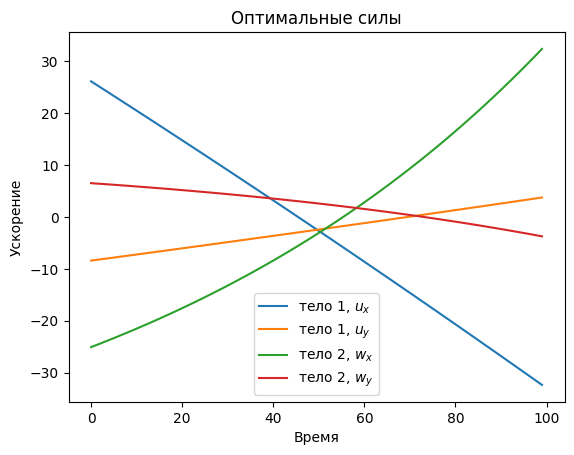

In [22]:
plt.title("Оптимальные силы")
plt.plot(u.value[0, :], label=r"тело 1, $u_x$")
plt.plot(u.value[1, :], label=r"тело 1, $u_y$")
plt.plot(w.value[0, :], label=r"тело 2, $w_x$")
plt.plot(w.value[1, :], label=r"тело 2, $w_y$")
plt.xlabel("Время")
plt.ylabel("Ускорение")
plt.legend()
plt.show()

# [SciPy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html)

- Функции (кроме функций `linprog` и `MILP`) принимают на вход черный ящик;
- Нужно самому имплементить градиенты и гессианы;
- Непосредственно к оптимизации относятся:
    - Функция `minimize_scalar` — для одномерной минимизации / линейного поиска;
    - Функция `minimize` — для локальной/выпуклой многомерной минимизации;
    - `linprog` и `MILP` — для линейного программирования и смешанного целочисленно-линейного программирования. Используется как солвер в CVXPY;
    - Функции из группы глобальной оптимизации: `basinhopping`, `simulated_annealing` и другие.

## [Локальная оптимизация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)

- Все алгоритмы в одной функции `minimize` указываются через опциональный аргумент `method=` или выбираются автоматически;

- Обязательно передать оракул нулевого порядка `fun=` и начальную точку `x0=`. Можно также передать функции вычисления градиента `jac=` и гессиана `hess=` или произведения гессиана на вектор `hessp=`. Если не передавать, могут быть примененены конечно-разностные схемы для их вычисления;

- Можно указать "коробочные" ограничения на значения переменных через аргумент `bounds=`, а также линейные или нелинейные ограничения через аргумент `constraints=`.

- Есть знакомые нам алгоритмы: `CG`, `BFGS`, `Newton-CG`, `L-BFGS`;

- Разные алгоритмы работают с разными оракулами и различаются по способности обрабатывать ограничения. Если не указывать алгоритм через аргумент `method=`, то SciPy будет использовать `BFGS`, `L-BFGS-B` или `SLSQP` в зависимости от наличия ограничений;

**Пример 11.** [Функция Розенброка](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A0%D0%BE%D0%B7%D0%B5%D0%BD%D0%B1%D1%80%D0%BE%D0%BA%D0%B0).

В двумерном случае выглядит следующим образом.

In [70]:
from scipy.optimize import rosen
from matplotlib import cm

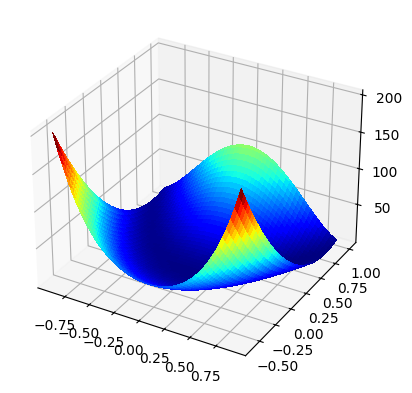

In [25]:
x = np.linspace(-0.9, 0.9, 100)
y = np.linspace(-0.6, 1, 100)
X, Y = np.meshgrid(x, y)
ax = plt.subplot(111, projection='3d')
ax.plot_surface(X, Y, rosen([X, Y]), cmap=cm.jet, linewidth=0, antialiased=False)
plt.show()

In [72]:
from scipy.optimize import minimize, rosen_der

In [28]:
x0 = np.random.random(20)

# Метод нулевого порядка
%timeit minimize(rosen, x0, method='Nelder-Mead', tol=1e-6)

# BFGS, градиент приближается конечными разностями
%timeit minimize(rosen, x0, method='BFGS', options={'gtol': 1e-6})

# BFGS, точный градиент 
%timeit minimize(rosen, x0, method='BFGS', jac=rosen_der, options={'gtol': 1e-6})

50.7 ms ± 1.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
25.6 ms ± 521 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
3.84 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


**Пример 12.** Задача коммивояжера. Найдём кратчайший цикл на полном графе на плоскости с евклидовым расстоянием между вершинами. 

Методы глобальной оптимизации в SciPy предназначены ддля минимизации функций на $\mathbb{R}^d$, поэтому нужен способ конвертации вектора из $\mathbb{R}^d$ в цикл на графе. Один из вариантов — определить порядок прохождения вершин равным порядку расположения компонент вектора после его сортировки, то есть сделать `argsort`. 

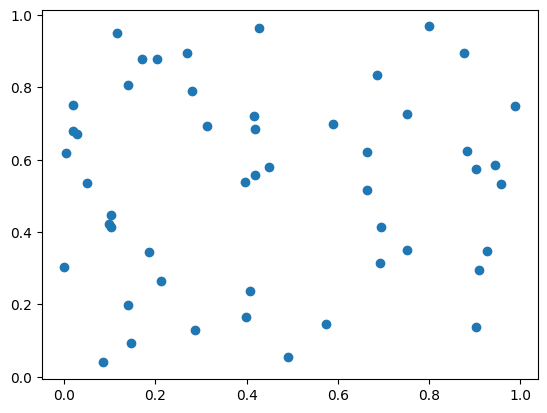

In [32]:
np.random.seed(1)

n = 50
points = np.random.random((n, 2))

plt.scatter(points[:, 0], points[:, 1])
plt.show()

In [33]:
# Функция подсчета длины пути
def path_len(path: np.ndarray):
    return (np.linalg.norm(points[np.roll(path, -1)] - points[path])).sum()

# Функция конвертации вектора из R^n в путь
def x_to_path(x: np.ndarray):
    return np.argsort(x)

# Целевая функция, определённая на R^n
def cost(x: np.ndarray):
    return path_len(x_to_path(x))

# Функция для рисования цикла, соответствующего вектору
def plot_x(x: np.ndarray):
    print(f"Длина пути = {cost(x)}")
    path = x_to_path(x)
    plt.scatter(points[:, 0], points[:, 1])
    plt.plot(*(points[np.hstack((path, path[0]))].T))
    plt.show()

Длина пути = 3.562723868320229


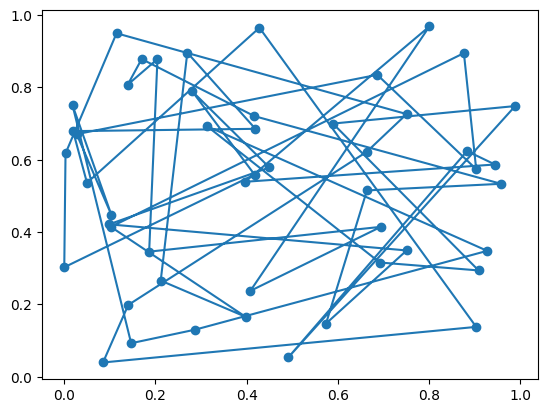

In [35]:
# Начальное приближение
x0 = np.random.random(n)
plot_x(x0)

In [73]:
from tqdm import tqdm
import time
from scipy.optimize import dual_annealing

100%|███████████████████████████████████████████| 10/10 [00:20<00:00,  2.09s/it]

Время выполнения: 20.895039081573486 секунд


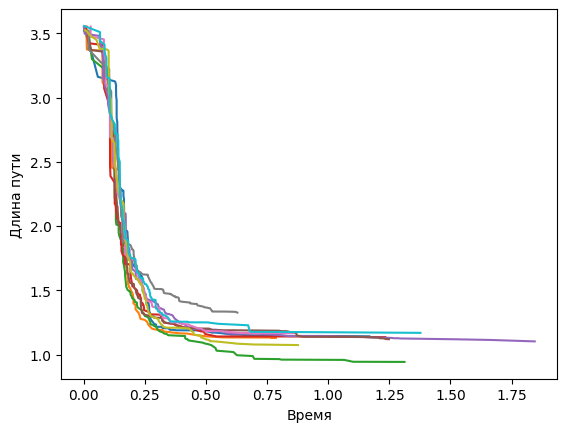

In [43]:
t0 = time.time()
xlog = []
for trial in tqdm(range(10)): 
    flog = []
    t = time.time()
    res = dual_annealing(cost, bounds=[[0, 1]] * n, x0=x0, maxiter=1000,
                         callback=lambda x, fval, _: flog.append((time.time() - t, fval)))
    
    plt.plot(*np.array(flog).T)
    xlog.append((res.x, res.fun))

print("Время выполнения:", time.time() - t0, "секунд")    

plt.ylabel("Длина пути")
plt.xlabel("Время")
plt.show()

In [44]:
print(res)

 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 1.1692174223365903
       x: [ 9.997e-01  6.775e-01 ...  3.020e-01  5.918e-01]
     nit: 1000
    nfev: 103520
    njev: 69
    nhev: 0


Длина пути = 0.9429655786805653


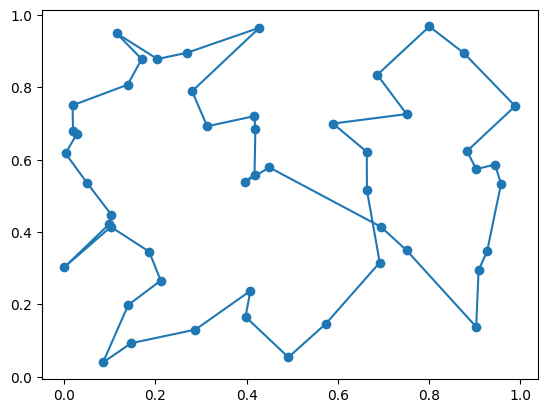

In [45]:
best_path_lens = [l[1] for l in xlog]
plot_x(xlog[np.argmin(best_path_lens)][0])

**Пример 12.** На этом [примере](https://en.wikipedia.org/wiki/Klee–Minty_cube) время работы симплекс-метода экспоненциально зависит от размерности задачи:

$$\begin{align*}
    \max_{x \in \mathbb{R}^d} ~~&~~ 2^{d - 1} x_1 + 2^{d - 2} x_2 + \dots + 2x_{d - 1} + x_d \\
    \text{s.t.} ~~&~~ x_1 \leq 5 \\
                ~~&~~ 4x_1 + x_2 \leq 25 \\
                ~~&~~ 8x_1 + 4x_2 + x_3 \leq 125 \\
                ~~&~~ \ldots \\
                ~~&~~ 2^d x_1 + 2^{d - 1} x_2 + \dots + x_d \leq 5^d \\
                ~~&~~ x_i \geq 0.
\end{align*}$$

Если начинать с точки $x_0 = 0$ и следовать симплекс-методу, то необходимо обойти $2^d - 1$ вершину.

In [55]:
def generate_problem(n):
    c = np.array([2**i for i in range(n)])
    c = c[::-1]
    bounds = [(0, None) for i in range(n)]
    b = np.array([5**(i + 1) for i in range(n)])
    a = np.array([1] + [2**(i + 1) for i in range(1, n)])
    A = np.zeros((n, n))
    for i in range(n):
        A[i:, i] = a[:n-i]
    return -c, A, b, bounds

In [74]:
from scipy.optimize import linprog
import warnings
warnings.filterwarnings("ignore")

In [66]:
n_list = range(3, 14)
n_iters = np.zeros(len(n_list))
times = np.zeros(len(n_list))
for i, n in enumerate(n_list):
    c, A, b, bounds = generate_problem(n)
    t0 = time.time()
    res = linprog(c, A, b, bounds=bounds, options={"maxiter": 2**max(n_list)}, method="revised simplex")
    n_iters[i] = res.nit
    times[i] = time.time() - t0

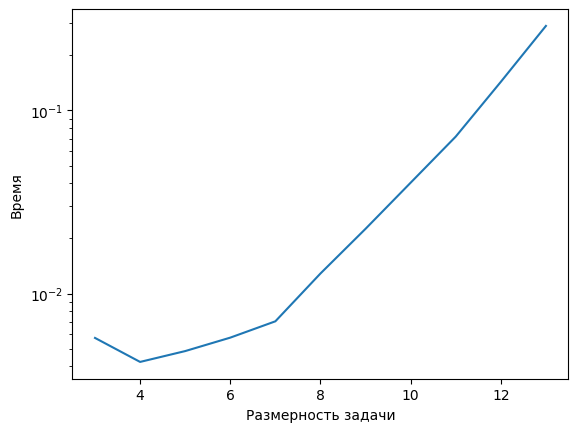

In [67]:
plt.plot(n_list, times)
plt.yscale("log")
plt.xlabel("Размерность задачи")
plt.ylabel("Время")
plt.show()